# Diabetic Retinopathy Subclassifier — Model 2 (Gaussian Filtered)

| | Value |
|---|---|
| Classes | Mild, Moderate, Proliferate_DR, Severe |
| Model | EfficientNetB3 |
| Input | 224×224 gaussian filtered images |
| Role | Stage 2 — runs only if Model 1 detects diabetic_retinopathy |

## Step 1: Imports

In [1]:
import os, time, itertools
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils.class_weight import compute_class_weight

import tensorflow.python.util.traceback_utils as _tb_utils
_tb_utils.filter_traceback = lambda f: f

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("TF version:", tf.__version__)
print("GPUs:", gpus)
print("Libraries loaded.")

TF version: 2.10.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Libraries loaded.


## Step 2: Configuration

In [2]:
DATA_DIR   = r"C:\Users\jayes\Desktop\Elements\MAJORPROJECT\MODEL3\dataset"
IMG_SIZE   = (224, 224)
BATCH_SIZE = 12
EPOCHS     = 40

print("Data dir exists:", os.path.exists(DATA_DIR))
if os.path.exists(DATA_DIR):
    for cls in sorted(os.listdir(DATA_DIR)):
        path = os.path.join(DATA_DIR, cls)
        if os.path.isdir(path):
            count = len([f for f in os.listdir(path)
                         if f.lower().endswith((".jpg",".jpeg",".png"))])
            print(f"  {cls}: {count} images")

Data dir exists: True
  Mild: 370 images
  Moderate: 999 images
  No_DR: 1805 images
  Proliferate_DR: 295 images
  Severe: 193 images


## Step 3: Load & Split Dataset (80/10/10)

In [3]:
def define_paths(data_dir):
    filepaths, labels = [], []
    for fold in os.listdir(data_dir):
        foldpath = os.path.join(data_dir, fold)
        if not os.path.isdir(foldpath):
            continue
        for file in os.listdir(foldpath):
            if file.lower().endswith((".jpg", ".jpeg", ".png")):
                filepaths.append(os.path.join(foldpath, file))
                labels.append(fold)
    return filepaths, labels

files, classes = define_paths(DATA_DIR)
df = pd.concat([
    pd.Series(files,   name="filepaths"),
    pd.Series(classes, name="labels")
], axis=1)

print("Class distribution:")
print(df["labels"].value_counts())
print(f"Total: {len(df)}")

train_df, dummy_df = train_test_split(df, train_size=0.8, shuffle=True,
                                      random_state=123, stratify=df["labels"])
valid_df, test_df  = train_test_split(dummy_df, train_size=0.5, shuffle=True,
                                      random_state=123, stratify=dummy_df["labels"])

print(f"Train: {len(train_df)} | Val: {len(valid_df)} | Test: {len(test_df)}")

Class distribution:
labels
No_DR             1805
Moderate           999
Mild               370
Proliferate_DR     295
Severe             193
Name: count, dtype: int64
Total: 3662
Train: 2929 | Val: 366 | Test: 367


## Step 4: Data Generators

In [4]:
def scalar(img):
    return img

ts_length = len(test_df)
test_batch_size = max(sorted([
    ts_length // n for n in range(1, ts_length + 1)
    if ts_length % n == 0 and ts_length / n <= 80
]))

tr_gen = ImageDataGenerator(
    preprocessing_function=scalar,
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=20,
    zoom_range=0.15,
    brightness_range=[0.8, 1.2]
)
ts_gen = ImageDataGenerator(preprocessing_function=scalar)

train_gen = tr_gen.flow_from_dataframe(
    train_df, x_col="filepaths", y_col="labels",
    target_size=IMG_SIZE, class_mode="categorical",
    color_mode="rgb", shuffle=True, batch_size=BATCH_SIZE
)
valid_gen = ts_gen.flow_from_dataframe(
    valid_df, x_col="filepaths", y_col="labels",
    target_size=IMG_SIZE, class_mode="categorical",
    color_mode="rgb", shuffle=False, batch_size=BATCH_SIZE
)
test_gen = ts_gen.flow_from_dataframe(
    test_df, x_col="filepaths", y_col="labels",
    target_size=IMG_SIZE, class_mode="categorical",
    color_mode="rgb", shuffle=False, batch_size=test_batch_size
)

CLASS_NAMES = list(train_gen.class_indices.keys())
NUM_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Num classes:", NUM_CLASSES)

Found 2929 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 367 validated image filenames belonging to 5 classes.
Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Num classes: 5


## Step 5: Build Model

In [5]:
img_shape = (IMG_SIZE[0], IMG_SIZE[1], 3)

base_model = tf.keras.applications.efficientnet.EfficientNetB3(
    include_top=False, weights="imagenet",
    input_shape=img_shape, pooling="max"
)

model = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
    Dense(256,
          kernel_regularizer=regularizers.l2(0.016),
          activity_regularizer=regularizers.l1(0.006),
          bias_regularizer=regularizers.l1(0.006),
          activation="relu"),
    Dropout(rate=0.45, seed=123),
    Dense(NUM_CLASSES, activation="softmax")
])

model.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetb3 (Functional)  (None, 1536)             10783535  
                                                                 
 batch_normalization (BatchN  (None, 1536)             6144      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 256)               393472    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 5)                 1285      
                                                                 
Total params: 11,184,436
Trainable params: 11,094,061
Non-trainable params: 90,375
_______________________________________

## Step 6: Custom Callback

In [6]:
class MyCallback(keras.callbacks.Callback):
    def __init__(self, model, patience, stop_patience, threshold, factor, batches, epochs):
        super(MyCallback, self).__init__()
        self.model         = model
        self.patience      = patience
        self.stop_patience = stop_patience
        self.threshold     = threshold
        self.factor        = factor
        self.batches       = batches
        self.epochs        = epochs
        self.count         = 0
        self.stop_count    = 0
        self.best_epoch    = 1
        self.highest_tracc = 0.0
        self.lowest_vloss  = np.inf
        self.best_weights  = self.model.get_weights()

    def on_train_begin(self, logs=None):
        print("{:^8s}{:^10s}{:^9s}{:^9s}{:^9s}{:^9s}{:^9s}{:^11s}{:^10s}{:^8s}".format(
            "Epoch","Loss","Accuracy","V_loss","V_acc","LR","Next LR","Monitor","% Improv","Duration"))
        self.start_time = time.time()

    def on_train_end(self, logs=None):
        elapsed = time.time() - self.start_time
        h = int(elapsed // 3600)
        m = int((elapsed % 3600) // 60)
        s = elapsed % 60
        print(f"Training time: {h}h {m}m {s:.1f}s")
        self.model.set_weights(self.best_weights)

    def on_train_batch_end(self, batch, logs=None):
        acc  = logs.get("accuracy", 0) * 100
        loss = logs.get("loss", 0)
        print(f"  batch {batch}/{self.batches} — acc: {acc:.2f}% loss: {loss:.4f}", end="\r")

    def on_epoch_begin(self, epoch, logs=None):
        self.ep_start = time.time()

    def on_epoch_end(self, epoch, logs=None):
        duration   = time.time() - self.ep_start
        lr         = float(tf.keras.backend.get_value(self.model.optimizer.lr))
        current_lr = lr
        acc    = logs.get("accuracy")
        v_acc  = logs.get("val_accuracy")
        loss   = logs.get("loss")
        v_loss = logs.get("val_loss")

        if acc < self.threshold:
            monitor = "accuracy"
            pimprov = 0.0 if epoch == 0 else (acc - self.highest_tracc)*100/max(self.highest_tracc,1e-8)
            if acc > self.highest_tracc:
                self.highest_tracc = acc
                self.best_weights  = self.model.get_weights()
                self.count = 0; self.stop_count = 0
                if v_loss < self.lowest_vloss: self.lowest_vloss = v_loss
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr *= self.factor
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                    self.count = 0; self.stop_count += 1
                    if v_loss < self.lowest_vloss: self.lowest_vloss = v_loss
                else:
                    self.count += 1
        else:
            monitor = "val_loss"
            pimprov = 0.0 if epoch == 0 else (self.lowest_vloss-v_loss)*100/max(self.lowest_vloss,1e-8)
            if v_loss < self.lowest_vloss:
                self.lowest_vloss = v_loss
                self.best_weights  = self.model.get_weights()
                self.count = 0; self.stop_count = 0
                self.best_epoch = epoch + 1
            else:
                if self.count >= self.patience - 1:
                    lr *= self.factor
                    self.stop_count += 1; self.count = 0
                    tf.keras.backend.set_value(self.model.optimizer.lr, lr)
                else:
                    self.count += 1
                if acc > self.highest_tracc: self.highest_tracc = acc

        print(f"{str(epoch+1):^3s}/{str(self.epochs):4s} {loss:^9.3f}{acc*100:^9.3f}"
              f"{v_loss:^9.5f}{v_acc*100:^9.3f}{current_lr:^9.5f}{lr:^9.5f}"
              f"{monitor:^11s}{pimprov:^10.2f}{duration:^8.2f}")

        if self.stop_count > self.stop_patience - 1:
            print(f"Training halted at epoch {epoch+1} — {self.stop_patience} LR reductions with no improvement.")
            self.model.stop_training = True

print("MyCallback defined.")

MyCallback defined.


## Step 7: Train Model

In [7]:
batches = int(np.ceil(len(train_gen.labels) / BATCH_SIZE))

callbacks = [MyCallback(
    model        = model,
    patience     = 1,
    stop_patience= 3,
    threshold    = 0.9,
    factor       = 0.5,
    batches      = batches,
    epochs       = EPOCHS
)]

history = model.fit(
    x               = train_gen,
    epochs          = EPOCHS,
    verbose         = 0,
    callbacks       = callbacks,
    validation_data = valid_gen,
    shuffle         = False
)

 Epoch     Loss   Accuracy  V_loss    V_acc     LR     Next LR   Monitor   % Improv Duration
 1 /40     7.408   65.005   5.93492  77.049   0.00100  0.00100  accuracy     0.00    142.72 
 2 /40     5.073   72.448   4.39077  67.213   0.00100  0.00100  accuracy    11.45    81.61  
 3 /40     3.651   75.145   3.08156  75.683   0.00100  0.00100  accuracy     3.72    81.04  
 4 /40     2.644   77.194   2.25013  78.962   0.00100  0.00100  accuracy     2.73    82.98  
 5 /40     1.923   78.115   1.68334  78.689   0.00100  0.00100  accuracy     1.19    83.44  
 6 /40     1.478   79.140   1.34630  82.240   0.00100  0.00100  accuracy     1.31    82.58  
 7 /40     1.217   79.003   1.05931  84.153   0.00100  0.00050  accuracy    -0.17    79.39  
 8 /40     1.010   82.485   1.03192  77.322   0.00050  0.00050  accuracy     4.23    83.26  
 9 /40     0.930   82.963   0.87193  80.874   0.00050  0.00050  accuracy     0.58    83.14  
10 /40     0.854   83.168   0.86674  78.689   0.00050  0.00050  accura

## Step 8: Training History

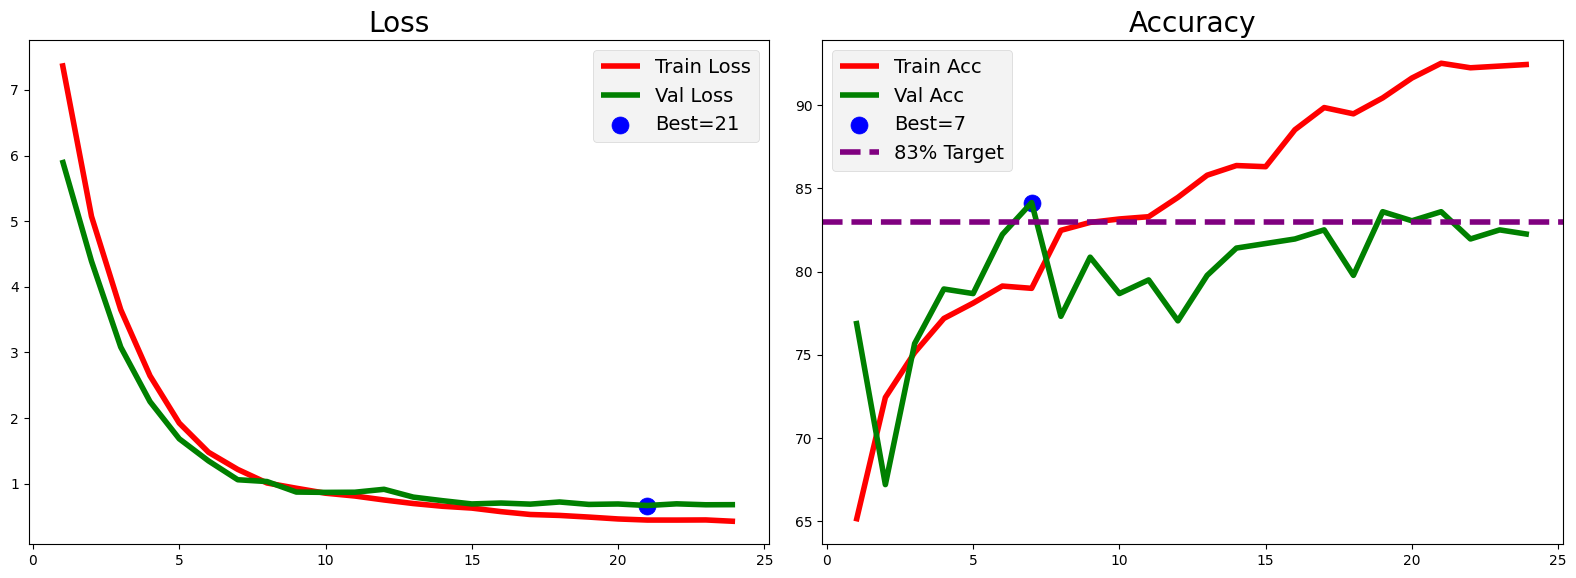

Best val accuracy: 84.15% at epoch 7


In [8]:
tr_acc   = history.history["accuracy"]
tr_loss  = history.history["loss"]
val_acc  = history.history["val_accuracy"]
val_loss = history.history["val_loss"]

idx_loss = np.argmin(val_loss)
idx_acc  = np.argmax(val_acc)
ep       = range(1, len(tr_acc)+1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plt.style.use("fivethirtyeight")

axes[0].plot(ep, tr_loss,  "r", label="Train Loss")
axes[0].plot(ep, val_loss, "g", label="Val Loss")
axes[0].scatter(idx_loss+1, val_loss[idx_loss], s=150, c="blue", label=f"Best={idx_loss+1}")
axes[0].set_title("Loss"); axes[0].legend()

axes[1].plot(ep, [a*100 for a in tr_acc],  "r", label="Train Acc")
axes[1].plot(ep, [a*100 for a in val_acc], "g", label="Val Acc")
axes[1].scatter(idx_acc+1, val_acc[idx_acc]*100, s=150, c="blue", label=f"Best={idx_acc+1}")
axes[1].axhline(y=83, color="purple", linestyle="--", label="83% Target")
axes[1].set_title("Accuracy"); axes[1].legend()

plt.tight_layout()
plt.savefig("dr_training_history.png", dpi=150)
plt.show()
print(f"Best val accuracy: {max(val_acc)*100:.2f}% at epoch {idx_acc+1}")

## Step 9: Evaluate on Test Set

In [9]:
ts_length   = len(test_df)
test_steps  = ts_length // test_batch_size

test_score = model.evaluate(test_gen, steps=test_steps, verbose=1)
print(f"Test Accuracy: {test_score[1]*100:.2f}%")
print(f"Test Loss:     {test_score[0]:.4f}")

367/367 [==============================] - 11s 29ms/step - loss: 0.6999 - accuracy: 0.8229
Test Accuracy: 82.29%
Test Loss:     0.6999


## Step 10: Confusion Matrix & Classification Report

367/367 [==============================] - 13s 26ms/step


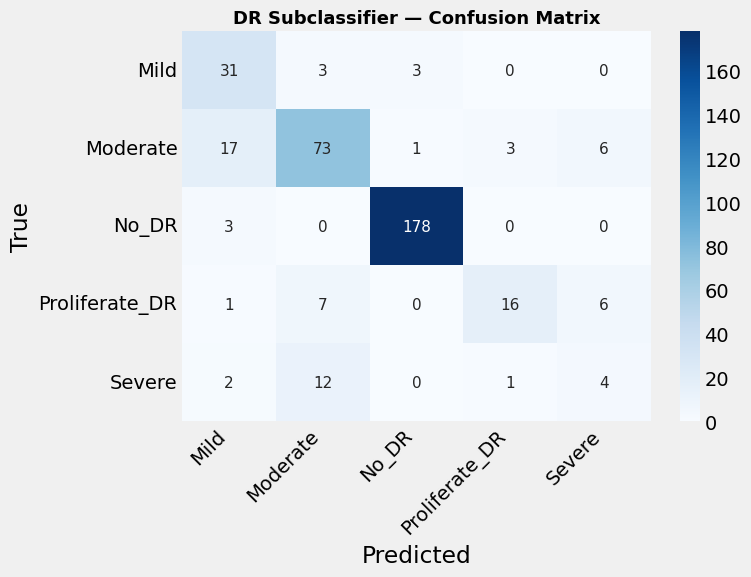

                precision    recall  f1-score   support

          Mild       0.57      0.84      0.68        37
      Moderate       0.77      0.73      0.75       100
         No_DR       0.98      0.98      0.98       181
Proliferate_DR       0.80      0.53      0.64        30
        Severe       0.25      0.21      0.23        19

      accuracy                           0.82       367
     macro avg       0.67      0.66      0.66       367
  weighted avg       0.83      0.82      0.82       367



In [10]:
preds  = model.predict(test_gen)
y_pred = np.argmax(preds, axis=1)
y_true = test_gen.classes
classes = list(test_gen.class_indices.keys())

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=classes, yticklabels=classes,
            annot_kws={"size": 11})
plt.title("DR Subclassifier — Confusion Matrix", fontsize=13, fontweight="bold")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("dr_confusion_matrix.png", dpi=150)
plt.show()
print(classification_report(y_true, y_pred, target_names=classes))

## Step 11: Per-Class Accuracy Chart

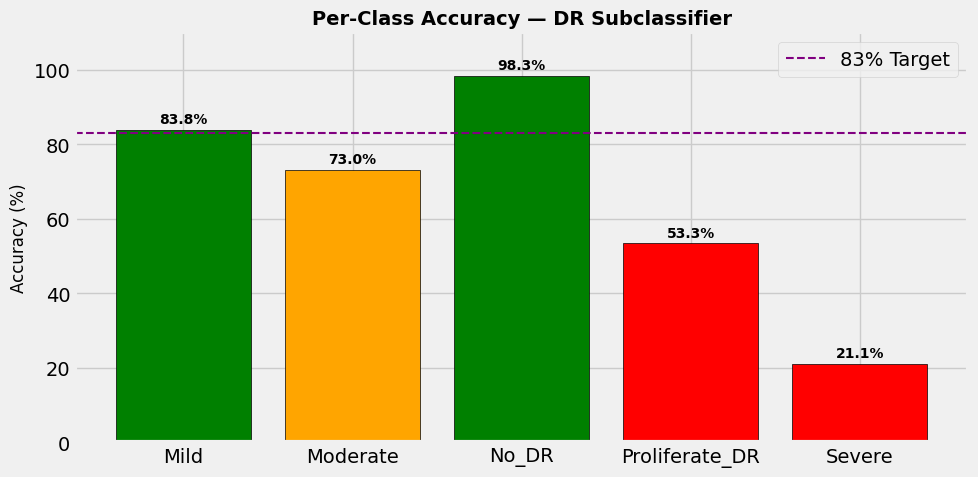

In [11]:
per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100

colors = ["green" if a >= 83 else "orange" if a >= 70 else "red"
          for a in per_class_acc]

plt.figure(figsize=(10, 5))
bars = plt.bar(classes, per_class_acc, color=colors, edgecolor="black", linewidth=0.5)
plt.axhline(y=83, color="purple", linestyle="--", linewidth=1.5, label="83% Target")
plt.ylabel("Accuracy (%)", fontsize=12)
plt.title("Per-Class Accuracy — DR Subclassifier", fontsize=14, fontweight="bold")
plt.ylim(0, 110)
plt.legend()

for bar, acc in zip(bars, per_class_acc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f"{acc:.1f}%", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("dr_per_class_accuracy.png", dpi=150)
plt.show()

## Step 12: ROC Curves

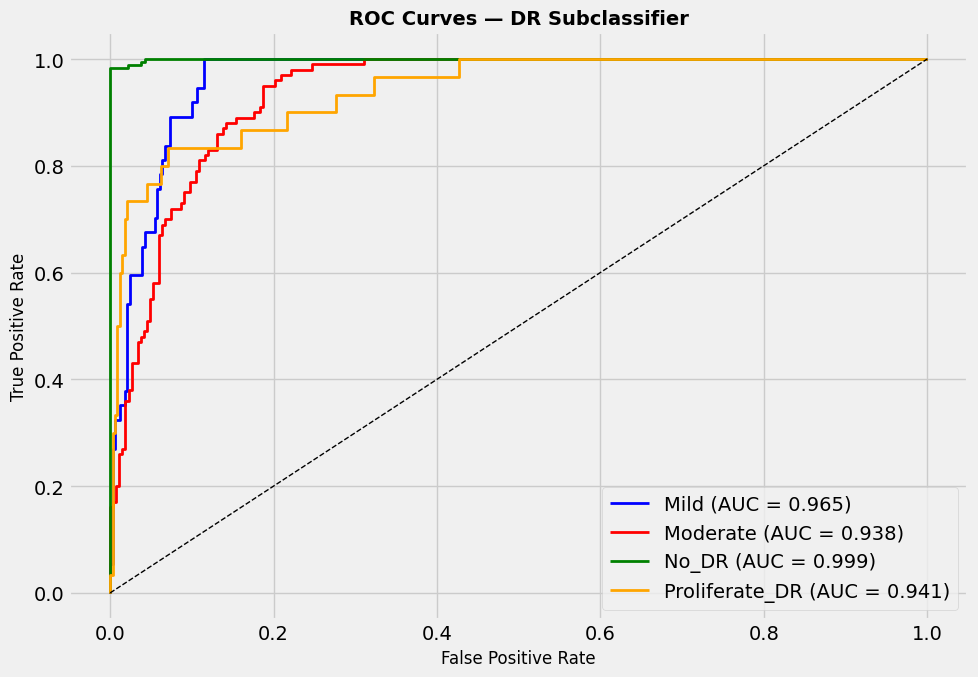

In [12]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

y_true_bin = label_binarize(y_true, classes=list(range(len(classes))))

plt.figure(figsize=(10, 7))
colors_roc = ["blue", "red", "green", "orange"]

for i, (cls, color) in enumerate(zip(classes, colors_roc)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], preds[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f"{cls} (AUC = {roc_auc:.3f})")

plt.plot([0,1],[0,1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves — DR Subclassifier", fontsize=14, fontweight="bold")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("dr_roc_curves.png", dpi=150)
plt.show()

## Step 13: Save Weights

In [13]:
best_weights = model.get_weights()
np.save("dr_subclassifier_weights.npy",
        np.array(best_weights, dtype=object),
        allow_pickle=True)
print("DR subclassifier weights saved -> dr_subclassifier_weights.npy")

try:
    model.save_weights("dr_subclassifier_weights.h5")
    print("H5 weights also saved!")
except Exception as e:
    print(f"H5 failed: {e} — but .npy is enough!")

print(f"Classes: {CLASS_NAMES}")
print(f"Best val accuracy: {max(val_acc)*100:.2f}%")

DR subclassifier weights saved -> dr_subclassifier_weights.npy
H5 weights also saved!
Classes: ['Mild', 'Moderate', 'No_DR', 'Proliferate_DR', 'Severe']
Best val accuracy: 84.15%


## Step 14: app.py Integration — Both Models

In [14]:
app_code = """
import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

MODEL1_CLASSES = ["ARMD", "cataract", "diabetic_retinopathy", "glaucoma", "normal"]
MODEL2_CLASSES = ["Mild", "Moderate", "Proliferate_DR", "Severe"]
MODEL1_WEIGHTS = "eye_disease_weights.npy"
MODEL2_WEIGHTS = "dr_subclassifier_weights.npy"

_model1 = None
_model2 = None

def build_efficientnetb3(num_classes):
    base = tf.keras.applications.efficientnet.EfficientNetB3(
        include_top=False, weights=None,
        input_shape=(224,224,3), pooling="max"
    )
    model = Sequential([
        base,
        BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
        Dense(256, kernel_regularizer=regularizers.l2(0.016),
              activity_regularizer=regularizers.l1(0.006),
              bias_regularizer=regularizers.l1(0.006), activation="relu"),
        Dropout(rate=0.45, seed=123),
        Dense(num_classes, activation="softmax")
    ])
    return model

def get_model1():
    global _model1
    if _model1 is None:
        _model1 = build_efficientnetb3(len(MODEL1_CLASSES))
        w = np.load(MODEL1_WEIGHTS, allow_pickle=True)
        _model1.set_weights(list(w))
    return _model1

def get_model2():
    global _model2
    if _model2 is None:
        _model2 = build_efficientnetb3(len(MODEL2_CLASSES))
        w = np.load(MODEL2_WEIGHTS, allow_pickle=True)
        _model2.set_weights(list(w))
    return _model2

def apply_gaussian_filter(img_array):
    img = img_array.astype(np.uint8)
    return cv2.addWeighted(img, 4,
           cv2.GaussianBlur(img, (0,0), 30), -4, 128)

def model_prediction(test_image_path):
    img = tf.keras.utils.load_img(test_image_path, target_size=(224, 224))
    x   = tf.keras.utils.img_to_array(img)
    x   = np.expand_dims(x, axis=0)

    # Stage 1 — detect disease
    pred1  = get_model1().predict(x, verbose=0)
    class1 = MODEL1_CLASSES[np.argmax(pred1)]

    # Stage 2 — if DR detected, classify subtype using gaussian filtered image
    if class1 == "diabetic_retinopathy":
        img_raw = tf.keras.utils.load_img(test_image_path, target_size=(224, 224))
        x_raw   = tf.keras.utils.img_to_array(img_raw)
        x_filt  = apply_gaussian_filter(x_raw)
        x_filt  = np.expand_dims(x_filt, axis=0)
        pred2   = get_model2().predict(x_filt, verbose=0)
        class2  = MODEL2_CLASSES[np.argmax(pred2)]
        return f"Diabetic Retinopathy — {class2}"

    return class1
"""
print(app_code)


import cv2
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras import regularizers

MODEL1_CLASSES = ["ARMD", "cataract", "diabetic_retinopathy", "glaucoma", "normal"]
MODEL2_CLASSES = ["Mild", "Moderate", "Proliferate_DR", "Severe"]
MODEL1_WEIGHTS = "eye_disease_weights.npy"
MODEL2_WEIGHTS = "dr_subclassifier_weights.npy"

_model1 = None
_model2 = None

def build_efficientnetb3(num_classes):
    base = tf.keras.applications.efficientnet.EfficientNetB3(
        include_top=False, weights=None,
        input_shape=(224,224,3), pooling="max"
    )
    model = Sequential([
        base,
        BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),
        Dense(256, kernel_regularizer=regularizers.l2(0.016),
              activity_regularizer=regularizers.l1(0.006),
              bias_regularizer=regularizers.l1(0.006), activation="relu"),
        Dropou